In [60]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from cosmopower import cosmopower_NN

# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using gpu:0 device 



2023-03-01 13:03:29.655311: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /device:GPU:0 with 38261 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2023-03-01 13:03:29.656301: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /device:GPU:1 with 38261 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2023-03-01 13:03:29.657291: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /device:GPU:2 with 38261 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
2023-03-01 13:03:29.658247: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /device:GPU:3 with 38261 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


In [61]:
subdir = "20230301_test_5000"
plots_dir = f"../plots/{subdir}/"
outdata_dir = f"../training_data/{subdir}/"
models_dir = f"../models/{subdir}/"

# l = np.load(outdata_dir + "l.npy")
l = np.logspace(2,np.log10(9000), 10)
p0s = np.load(outdata_dir + "data.npy")
cosmology = np.load(outdata_dir + "cosmology.npy")

# (Omega_b, Omega_m, h, ln(10^10 A_s), n_s)
model_parameters = ['Omega_b',
                    'Omega_m',
                    'h',
                    'A_s', 
                    'n_s', 
                    ]

In [62]:
print(p0s.shape, cosmology.shape)
yes_data = np.sum(np.isnan(p0s), axis=1) == 0
p0s, cosmology = p0s[yes_data], cosmology[yes_data]
print(p0s.shape, cosmology.shape)

(5000, 10) (5000, 5)
(4696, 10) (4696, 5)


In [63]:
train_p0s, test_p0s = p0s[:4000], p0s[4000:]
train_cosmology, test_cosmology = cosmology[:4000], cosmology[4000:]

In [64]:
# parameter ranges for (Omega_b, Omega_m, h, ln(10^10 A_s), n_s)
# ranges = np.array([[0.01, 0.05], [0.1, 0.5], [0.6, 0.9], [1.7, 3.9], [0.8, 1.2]])

training_parameters = {model_parameters[i]: train_cosmology[:, i] for i in range(len(model_parameters))}
training_log_spectra = np.log(train_p0s)

print(training_parameters['h'].shape, training_log_spectra.shape)

testing_parameters = {model_parameters[i]: test_cosmology[:, i] for i in range(len(model_parameters))}
testing_log_spectra = np.log(test_p0s)

print(testing_parameters['h'].shape, testing_log_spectra.shape)

(4000,) (4000, 10)
(696,) (696, 10)


In [56]:
cp_nn = cosmopower_NN(parameters=model_parameters, 
                      modes=l, 
                      n_hidden = [512, 512, 512, 512], # 4 hidden layers, each with 512 nodes
                      verbose=True, # useful to understand the different steps in initialisation and training
                      )


Initialized cosmopower_NN model, 
mapping 5 input parameters to 10 output modes, 
using 4 hidden layers, 
with [512, 512, 512, 512] nodes, respectively. 



In [57]:
with tf.device(device):
    # train
    cp_nn.train(training_parameters=training_parameters,
                training_features=training_log_spectra,
                filename_saved_model=models_dir + 'kappa',
                # cooling schedule
                validation_split=0.1,
                learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6],
                batch_sizes=[1024, 1024, 1024, 1024, 1024],
                gradient_accumulation_steps = [1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [100,100,100,100,100],
                max_epochs = [1000,1000,1000,1000,1000],
                )

Starting cosmopower_NN training, 
using 10 per cent of training samples for validation. 
Performing 5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] learning rates 
[1024, 1024, 1024, 1024, 1024] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps 
[100, 100, 100, 100, 100] patience values 
[1000, 1000, 1000, 1000, 1000] max epochs 

learning rate = 0.01, batch size = 1024


 32%|███▏      | 321/1000 [00:18<00:39, 17.25it/s, loss=0.115] 


Validation loss = 0.06655165
Model saved.
Reached max number of epochs. Validation loss = 0.06655165
Model saved.
learning rate = 0.001, batch size = 1024


 48%|████▊     | 485/1000 [00:25<00:26, 19.18it/s, loss=0.0181]


Validation loss = 0.010388106
Model saved.
Reached max number of epochs. Validation loss = 0.010388106
Model saved.
learning rate = 0.0001, batch size = 1024


...

Validation loss = 0.0065046013
Model saved.
Reached max number of epochs. Validation loss = 0.0065046013
Model saved.
learning rate = 1e-05, batch size = 1024


 10%|█         | 100/1000 [00:05<00:47, 18.89it/s, loss=0.00647]


Validation loss = 0.006145499
Model saved.
Reached max number of epochs. Validation loss = 0.006145499
Model saved.
learning rate = 1e-06, batch size = 1024


 10%|█         | 100/1000 [00:05<00:48, 18.62it/s, loss=0.00751]

Validation loss = 0.007390722
Model saved.
Reached max number of epochs. Validation loss = 0.007390722
Model saved.


In [90]:
cp_nn = cosmopower_NN(restore=True, 
                      restore_filename=models_dir + 'kappa',
                      )
predicted_testing_spectra = np.exp(cp_nn.predictions_np(testing_parameters))
testing_spectra = np.exp(testing_log_spectra)

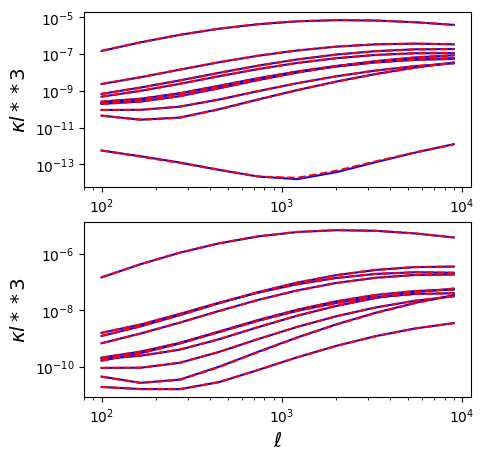

In [96]:
from matplotlib import gridspec
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(5,5))
for i in range(2):
    for j in range(10):
        pred = predicted_testing_spectra[(i+1)*j + 100]*l**3
        true = testing_spectra[(i+1)*j + 100]*l**3
        ax[i].plot(l, true, 'blue', label = 'Original')
        ax[i].plot(l, pred, 'red', label = 'NN reconstructed', linestyle='--')
        ax[i].set_xlabel('$\ell$', fontsize='x-large')
        ax[i].set_ylabel('$\kappa l**3$', fontsize='x-large')
        # ax[i].legend(fontsize=15)
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
# plt.savefig('examples_reconstruction_TT.pdf')